# Neural posterior estimation: training and evaluation

This notebook trains a neural posterior estimator (NPE) for the moment tensor of a synthetic
event and checks its calibration. It follows the steps of `scripts/train_NPE.py`: parse a
configuration, simulate a training set, build the dataset with its noise and training-time
augmentation, train an embedding network and a normalising flow, and evaluate the posterior on
held-out simulations with TARP coverage. The configuration is `configs/npe_example.yaml`: five
stations recording the vertical component, white Gaussian noise, and a random per-station
timing error applied as training-time augmentation.

The network is deliberately small and trained for a few minutes on a CPU; a production model
is larger and is trained on ~10⁵ simulations for hundreds of epochs on a GPU.

**Requirements**: `INSTASEIS_DB` pointing at a local Instaseis database. Nothing is downloaded.
Training is random, so the loss curve and the posteriors differ a little from run to run.

In [1]:
import os
import shutil
import tempfile
from copy import deepcopy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import SVG, Image, display

from seismo_sbi.sbi.configuration import SBI_Configuration

CONFIG_PATH = "configs/npe_example.yaml"
EPOCHS = 40
PARAMETER_NAMES = ["m_rr", "m_tt", "m_pp", "m_rt", "m_rp", "m_tp"]
scratch = Path(tempfile.mkdtemp())

config = SBI_Configuration.from_file(CONFIG_PATH, output_directory=scratch,
                                     database_path=os.environ["INSTASEIS_DB"])
training = config.training.apply_overrides(epochs=EPOCHS)
print("inferred parameters:", config.model_parameters.names)
print("prior bounds (N m):", config.model_parameters.bounds["moment_tensor"])
print("training noise:", config.sbi_noise_model)
print("station encoder:", training.encoder.station_encoder, training.encoder.options)

inferred parameters: {'moment_tensor': ['m_rr', 'm_tt', 'm_pp', 'm_rt', 'm_rp', 'm_tp']}
prior bounds (N m): [[-2e+17, -2e+17, -2e+17, -2e+17, -2e+17, -2e+17], [2e+17, 2e+17, 2e+17, 2e+17, 2e+17, 2e+17]]
training noise: {'type': 'gaussian', 'noise_level': 3e-06}
station encoder: tcn {'channels': 16, 'n_blocks': 2, 'kernel_size': 3, 'downsample': 4}


## The training set

`build_pipeline` builds the forward model and parameter sampler the configuration describes, and
`generate_training_dataset` simulates `jobs.simulations.random_events` sources drawn from the
prior, one HDF5 file each. The timing error is staged `training_augmentation`, so it is not
baked into the simulations: they stay clean and noise-free.

In [2]:
from seismo_sbi.sbi.datasets.training_data import build_pipeline, generate_training_dataset

np.random.seed(0)
pipeline = build_pipeline(config, CONFIG_PATH)
simulation_paths = generate_training_dataset(pipeline, config, training.skip_compression_stencil)
original_parameters = deepcopy(pipeline.parameters)
print("data vector length:", pipeline.data_vector_length, "=", len(pipeline.simulation_parameters.receivers),
      "stations x", pipeline.trace_length, "samples")

Training dataset ready: 3000 simulations at /tmp/tmpglklgn95/sims/npe_example/results
data vector length: 505 = 5 stations x 101 samples


## Noise and augmentation

`prepare_training_data` loads the training noise sampler, builds the augmentation chains from
the nuisance parameters staged for training, and the scaler that maps the moment tensor to the
unit box the flow works in. `TorchSimulationDataset` then serves each simulation with a fresh
draw of the augmentation and the noise every time it is read, so every epoch sees new
realisations of the same sources.

Training-time nuisance augmentation: ['time_shift_error']
Post-noise augmentation: none
Moment-tensor scaling: linear
Found 3000 simulations matching *.h5 under /tmp/tmpglklgn95/sims/npe_example/results


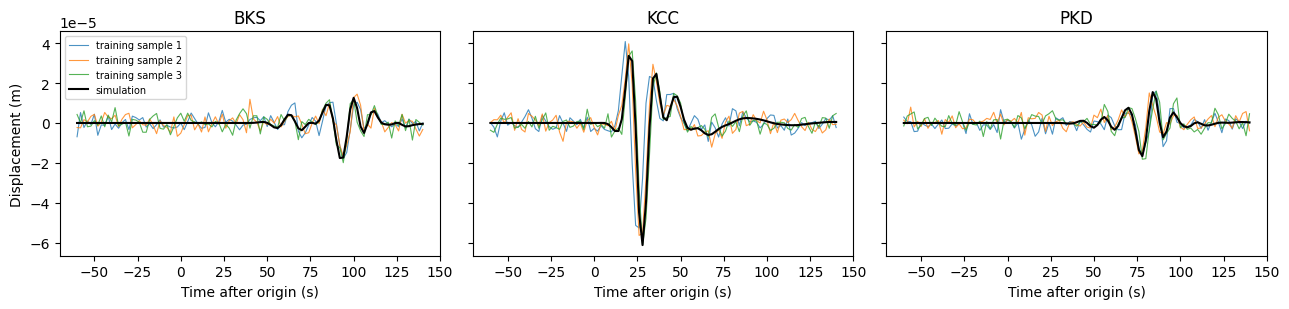

scaled parameters of this source: [0.549 0.715 0.603 0.545 0.424 0.646]


In [3]:
from seismo_sbi.sbi.npe.data.dataloading import TorchSimulationDataset
from seismo_sbi.sbi.datasets.training_data import prepare_training_data
from seismo_sbi.simulators.instaseis.querier import SYNTHETICS_PRE_EVENT_PAD_S

data = prepare_training_data(pipeline, config, simulation_paths, training)
dataset = TorchSimulationDataset(**training.dataset_args(pipeline, data))
clean = pipeline.data_manager.data_loader.load_simulation_data_array(dataset.paths[0], stacked=True)

np.random.seed(1)
time_s = np.arange(pipeline.trace_length) / pipeline.simulation_parameters.sampling_rate - SYNTHETICS_PRE_EVENT_PAD_S
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2), sharey=True)
for ax, station in zip(axes, [0, 2, 4]):
    for draw in range(3):
        scaled_theta, noisy = dataset[0]
        ax.plot(time_s, noisy[station, 0].numpy(), lw=0.8, alpha=0.8, label=f"training sample {draw + 1}")
    ax.plot(time_s, clean[station, 0], "k", lw=1.5, label="simulation")
    ax.set_title(pipeline.simulation_parameters.receivers.receivers[station].station_name)
    ax.set_xlabel("Time after origin (s)")
axes[0].set_ylabel("Displacement (m)")
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()
print("scaled parameters of this source:", np.round(scaled_theta.numpy(), 3))

## Training

`CompressionTrainer` pairs an embedding network, which compresses the seismograms of all
stations to a short summary, with a conditional normalising flow over the scaled moment
tensor. Training maximises the flow's log-probability of the true source given the data;
the last 10 % of the simulations are held out for validation. Metrics go to a CSV file.

TPU available: False, using: 0 TPU cores


IPU available: False, using: 0 IPUs


HPU available: False, using: 0 HPUs


CSV metrics logging to /tmp/tmpglklgn95/npe_example/results/npe_example/metrics.csv
Found 3000 simulations matching *.h5 under /tmp/tmpglklgn95/sims/npe_example/results


`Trainer.fit` stopped: `max_epochs=40` reached.


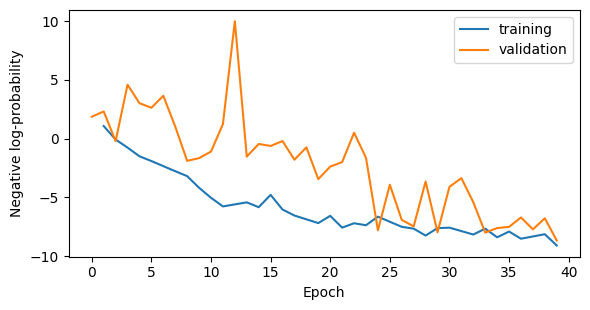

In [4]:
from dataclasses import replace

from seismo_sbi.sbi.npe.training.train import CompressionTrainer, attach_loggers

trainer = CompressionTrainer.from_training_data(replace(training, model_dim=32), data, layers=1)
run_directory = pipeline.models_output_path / "npe_example"
trainer.train("npe_example", epochs=training.epochs, output_path=pipeline.models_output_path,
              dataloader_args=training.dataloader_args(pipeline, data),
              logger=attach_loggers(training.logging, run_directory), enable_progress_bar=False)

metrics = pd.read_csv(run_directory / "metrics.csv")
fig, ax = plt.subplots(figsize=(6, 3.2))
for column, label in [("loss", "training"), ("val_loss", "validation")]:
    losses = metrics.dropna(subset=[column])
    ax.plot(losses["epoch"], losses[column], label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Negative log-probability")
ax.legend()
plt.tight_layout()
plt.show()

## Posteriors for held-out simulations

`build_posterior` wraps the trained flow as an `sbi` posterior over the unit box.
`run_validation` draws the held-out simulations with the same noise and augmentation the model
trained on and samples the posterior for each. For one of them we compare the posterior with
the prior and the true source.

Found 3000 simulations matching *.h5 under /tmp/tmpglklgn95/sims/npe_example/results
  validation: 200 held-out sims (tail of 3000), 1000 samples each; conditioned=False; path=direct (fixed-station).


    …25/200 val sims sampled


    …50/200 val sims sampled


    …75/200 val sims sampled


    …100/200 val sims sampled


    …125/200 val sims sampled


    …150/200 val sims sampled


    …175/200 val sims sampled


    …200/200 val sims sampled


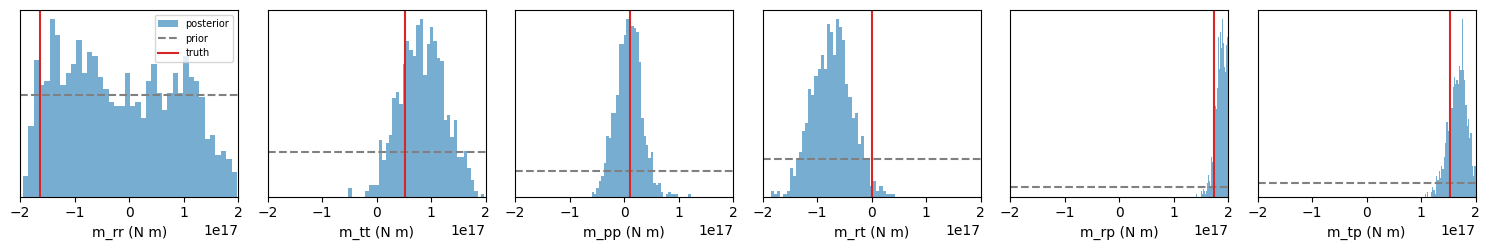

posterior std / prior std, averaged over held-out simulations: [0.75 0.26 0.18 0.23 0.16 0.13]


In [5]:
from seismo_sbi.evaluation.validation import run_validation, write_validation_outputs

posterior = trainer.build_posterior()
validation = run_validation(pipeline, original_parameters, posterior, data.data_scaler,
                            n_val=200, num_samples=1000, variable_stations=False)

lower, upper = config.model_parameters.bounds["moment_tensor"]
fig, axes = plt.subplots(1, 6, figsize=(15, 2.6))
for parameter, ax in enumerate(axes):
    ax.hist(validation["samples_phys"][:, 0, parameter], bins=40, density=True, color="C0", alpha=0.6,
            label="posterior")
    ax.axhline(1 / (upper[parameter] - lower[parameter]), color="grey", ls="--", label="prior")
    ax.axvline(validation["theta_phys"][0, parameter], color="C3", label="truth")
    ax.set_xlim(lower[parameter], upper[parameter])
    ax.set_xlabel(f"{PARAMETER_NAMES[parameter]} (N m)")
    ax.set_yticks([])
axes[0].legend(fontsize=7)
plt.tight_layout()
plt.show()

prior_std = (np.array(upper) - np.array(lower)) / np.sqrt(12)
posterior_std = validation["samples_phys"].std(axis=0).mean(axis=0)
print("posterior std / prior std, averaged over held-out simulations:", np.round(posterior_std / prior_std, 2))

## Calibration

A posterior can be narrow and wrong. TARP (Lemos et al. 2023) tests calibration without
assuming a shape: for a calibrated posterior the expected coverage of its credible regions
equals their credibility, the diagonal. A curve above the diagonal means the credible regions
are too wide, which is what a briefly trained model gives; below it, too narrow.
`write_validation_outputs` draws the TARP curve and the recovery of source type and magnitude,
and writes the metrics to JSON.

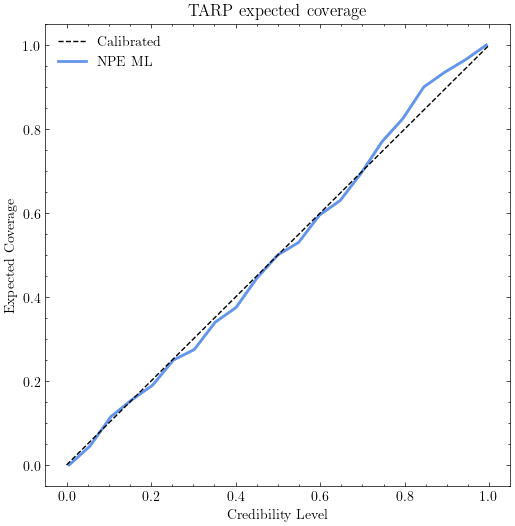

    wrote TARP coverage -> /tmp/tmpglklgn95/validation/tarp_coverage.png


    wrote recovery scatter -> /tmp/tmpglklgn95/validation/recovery_scatter.svg
Added lune kwargs


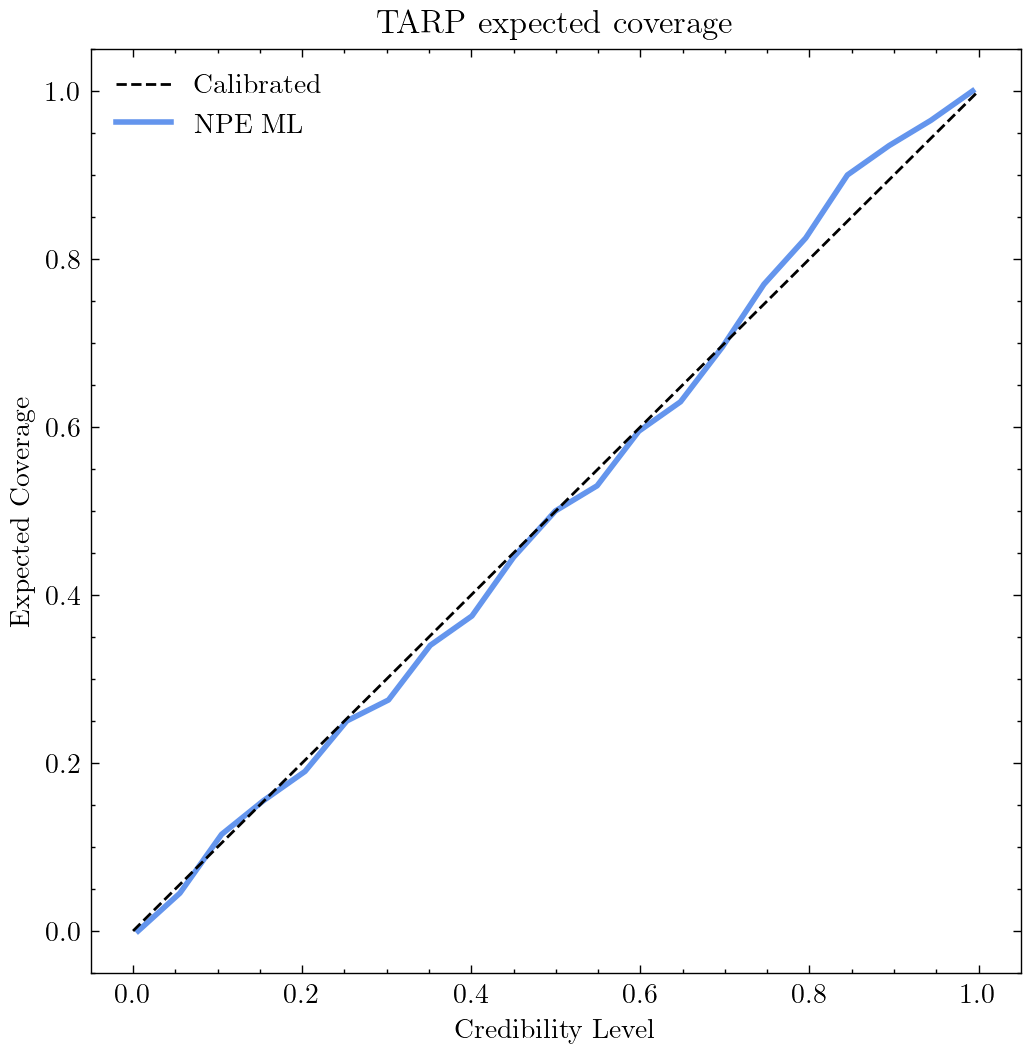

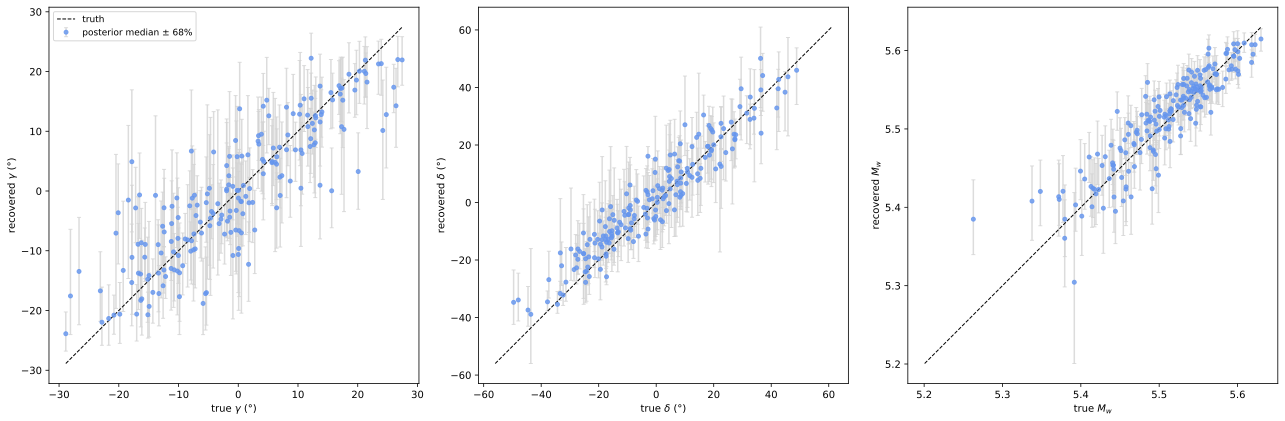

TARP calibration error: 0.016


In [6]:
validation_summary = write_validation_outputs(validation, scratch / "validation", original_parameters,
                                   data.data_scaler, num_samples=1000, conditioned=False, n_show=1)
display(Image(filename=str(scratch / "validation" / "tarp_coverage.png"), width=420))
display(SVG(filename=str(scratch / "validation" / "recovery_scatter.svg")))
print(f"TARP calibration error: {validation_summary['metrics']['coverage']['tarp_calibration_error']:.3f}")

In [7]:
shutil.rmtree(scratch)